In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [99]:
message = pd.read_csv('D:/countryedu_projects/ai4i2020.csv')
print(message.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [100]:
print(message.shape)
print(message.info())
print(message.describe())

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9

In [101]:
message.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [102]:
dataset = message.drop(["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)

In [103]:
dataset.dtypes

Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object

In [105]:
for i in dataset.select_dtypes(include=np.number).columns:
    dataset[i] = dataset[i].fillna(dataset[i].median())

dataset["Type"] = dataset["Type"].fillna(dataset["Type"].mode()[0])

In [107]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for i in features:
    dataset [i] = pd.to_numeric(dataset [i], errors='coerce')


In [111]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_cols:
    q1 = dataset[col].quantile(0.25)
    q3 = dataset    [col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    dataset[col] = dataset[col].clip(lower, upper)

In [112]:
dataset["temperature_difference"] = (
    dataset["Process temperature [K]"] - dataset["Air temperature [K]"]
)

dataset["power_proxy"] = (
    dataset["Torque [Nm]"] * dataset["Rotational speed [rpm]"]
)

dataset["wear_torque"] = (
    dataset["Tool wear [min]"] * dataset["Torque [Nm]"]
)

In [123]:
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,power_proxy,wear_torque
0,2,298.1,308.6,1551.0,42.8,0,0,10.5,66382.8,0.0
1,1,298.2,308.7,1408.0,46.3,3,0,10.5,65190.4,138.9
2,1,298.1,308.5,1498.0,49.4,5,0,10.4,74001.2,247.0
3,1,298.2,308.6,1433.0,39.5,7,0,10.4,56603.5,276.5
4,1,298.2,308.7,1408.0,40.0,9,0,10.5,56320.0,360.0
...,...,...,...,...,...,...,...,...,...,...
9995,2,298.8,308.4,1604.0,29.5,14,0,9.6,47318.0,413.0
9996,0,298.9,308.4,1632.0,31.8,17,0,9.5,51897.6,540.6
9997,2,299.0,308.6,1645.0,33.4,22,0,9.6,54943.0,734.8
9998,0,299.0,308.7,1408.0,48.5,25,0,9.7,68288.0,1212.5


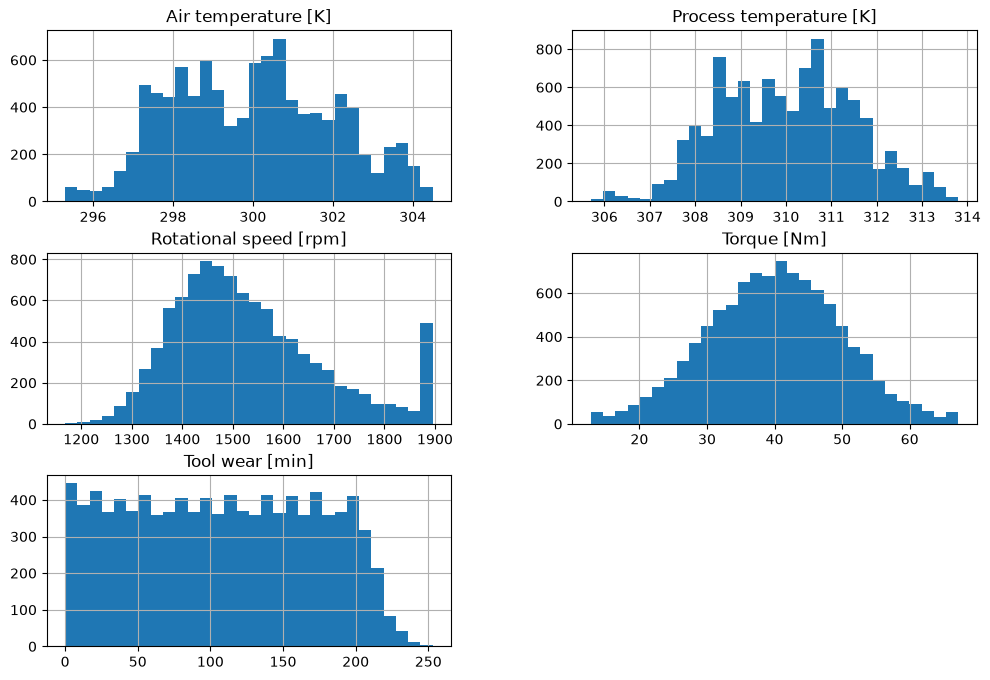

In [ ]:
dataset[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.show()

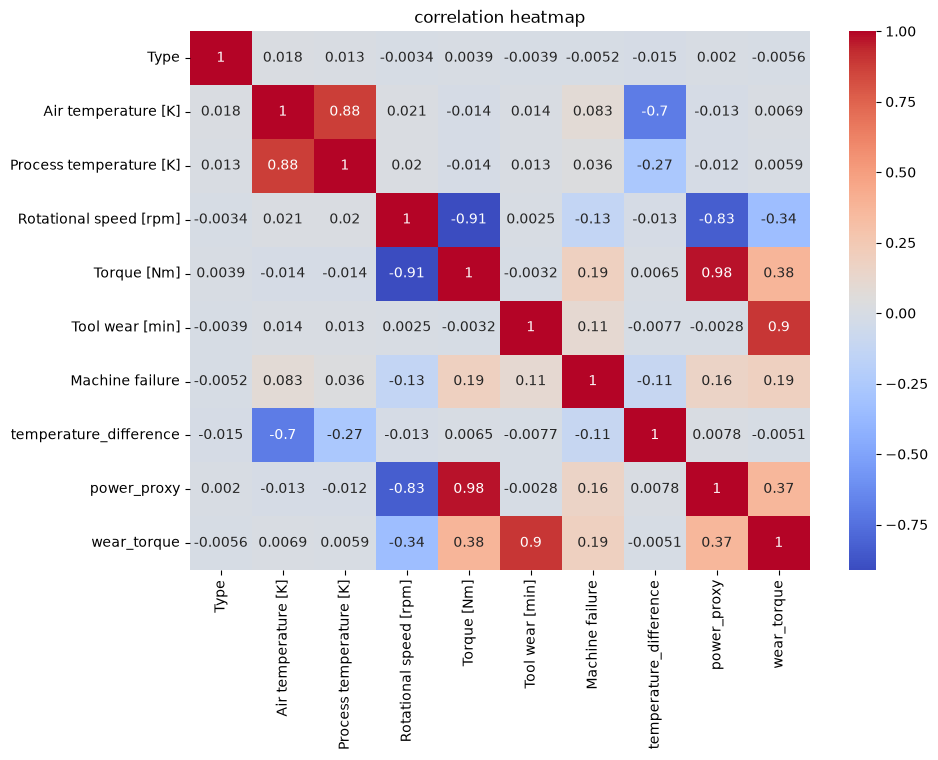

In [126]:
plt.figure(figsize=(10, 7))
sns.heatmap(dataset.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

In [115]:
encoder = LabelEncoder()
dataset["Type"] = encoder.fit_transform(dataset["Type"])

In [116]:
X = dataset.drop("Machine failure", axis=1)
y = dataset["Machine failure"]

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [ ]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.84      0.85        68

    accuracy                           0.99      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score: 0.9772142552673244


In [120]:
def recommend_maintenance(probability):
    if probability >= 0.70:
        return "High risk: perform urgent preventive maintenance."
    elif probability >= 0.35:
        return "Medium risk: schedule inspection within 7 days."
    return "Low risk: continue monitoring."

In [121]:
example = X_test_scaled[0].reshape(1, -1)
failure_probability = model.predict_proba(example)[0][1]

print("Failure probability:", round(failure_probability * 100, 2), "%")
print(recommend_maintenance(failure_probability))

Failure probability: 24.33 %
Low risk: continue monitoring.


In [122]:
import joblib

model_package = {
    "model": model,
    "scaler": scaler,
    "feature_names": list(X.columns)
}

joblib.dump(model_package, "predictive_maintenance_model.joblib")
print("Model saved successfully.")

Model saved successfully.
